In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp


In [2]:
adata = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_manual_annotation_with_raw.h5ad')
CELLTYPES_TO_KEEP = [
    # --- Astrocytes ---
    "Telencephalon astrocytes",
    "Olfactory astrocytes",

    # --- Oligodendrocyte lineage ---
    "Mature oligodendrocytes",
    "Oligodendrocytes precursor cells",

    # --- Microglia ---
    "Microglia",
]  # e.g., ["Mature oligodendrocytes", "Microglia"]
adata = adata[adata.obs.cell_class.isin(CELLTYPES_TO_KEEP)]

In [3]:
# ==== Install (first time only) ====
# %pip install pandas numpy scipy anndata seaborn matplotlib pymc arviz tqdm

import numpy as np
import pandas as pd
import anndata as ad
from scipy.sparse import issparse
from tqdm import tqdm

# -----------------------------
# Configuration (edit these)
# -----------------------------
CELLTYPE_COL  = "cell_class"   # column in adata.obs
SAMPLE_COL    = "sample_id"
AGE_COL       = "age"
COND_COL      = "condition"    # (e.g., "control" vs "mtdsb")
LAYER_COUNTS  = "counts"       # if absent we'll use .X


# -----------------------------
# Utility: pseudobulk by groups
# -----------------------------
import numpy as np
import pandas as pd
import scipy.sparse as sp

# --- tell the code where the counts live ---
LAYER_COUNTS = "counts"   # change if your raw counts are in another layer
CELLTYPE_COL = "cell_class"   # or whatever column you’re using
SAMPLE_COL   = "sample_id"    # sample in .obs
AGE_COL      = "age"
COND_COL     = "condition"

def _as_csr(X):
    if sp.issparse(X):
        return X.tocsr()
    # dense -> csr
    return sp.csr_matrix(np.asarray(X), copy=False)

def pseudobulk_by_groups(adata, group_cols, layer=None, keep_celltypes=None):
    """
    Sum raw counts per (celltype, sample, age, condition).
    Returns:
      pb_counts : dense float32 array (n_groups x n_genes)
      groups_df : dataframe with group labels (n_groups x len(group_cols))
      var_names : pandas Index of gene names
    """
    # 0) pull matrix & obs
    if layer is None:
        X = _as_csr(adata.X)
    else:
        if layer not in adata.layers:
            raise ValueError(f"Layer '{layer}' not found in adata.layers")
        X = _as_csr(adata.layers[layer])

    obs = adata.obs.copy()

    # 1) optional filter of cell types
    if keep_celltypes is not None:
        obs = obs.loc[obs[CELLTYPE_COL].isin(keep_celltypes)]
        X   = X[obs.index, :]   # keep matrix aligned

    # 2) make sure group columns exist and are strings (avoid categorical gotchas)
    for c in group_cols:
        if c not in obs.columns:
            raise ValueError(f"Missing obs column: {c}")
    gdf = obs.loc[:, group_cols].astype(str).copy()

    # 3) build an integer code per group
    key = pd.MultiIndex.from_frame(gdf, names=group_cols)
    codes, uniques = pd.factorize(key, sort=True)

    # 4) aggregate counts by group using a sparse trick
    n_groups = len(uniques)
    n_genes  = X.shape[1]
    ones     = np.ones(X.shape[0], dtype=np.int64)
    row_idx  = codes  # which group each cell belongs to

    # make a sparse "group-by" matrix G (cells -> groups), then G @ X = group sums
    G = sp.csr_matrix((ones, (row_idx, np.arange(X.shape[0]))), shape=(n_groups, X.shape[0]))
    pb_sparse = G @ X
    pb_counts = np.asarray(pb_sparse.todense(), dtype=np.float32)

    # 5) unpack group labels
    groups_df = uniques.to_frame(index=False)  # columns=group_cols
    groups_df.columns = group_cols

    return pb_counts, groups_df.reset_index(drop=True), adata.var_names.copy()
# -----------------------------
# CPM + log1p normalization
# -----------------------------
def normalize_pseudobulk(pb_counts, axis=1, libsize_scale=1e6):
    """
    CPM + log1p with zero-safe division.
    axis=1 means library size per row (sample/group).
    """
    X = np.asarray(pb_counts, dtype=np.float32)
    if axis == 1:
        lib = X.sum(1, keepdims=True)  # group sums
    else:
        lib = X.sum(0, keepdims=True)

    # avoid /0 -> NaN
    lib = np.where(lib == 0.0, 1.0, lib)
    X_cpm = (X / lib) * libsize_scale
    return np.log1p(X_cpm).astype(np.float32)

# -----------------------------
# Long-format builder
# -----------------------------
def pseudobulk_to_long_with_celltype(pb_norm, groups_df, var_names,
                                     sample_col=SAMPLE_COL, age_col=AGE_COL,
                                     cond_col=COND_COL, celltype_col=CELLTYPE_COL,
                                     value_name="value"):
    """
    Returns tidy df: [sample, age, condition, cell_type, gene, value]
    """
    n_groups, n_genes = pb_norm.shape
    assert n_groups == len(groups_df), "shape mismatch"

    # build a dataframe carefully
    df = pd.DataFrame(pb_norm, columns=var_names)
    df.insert(0, sample_col, groups_df[sample_col].values)
    df.insert(1, age_col,    groups_df[age_col].values)
    df.insert(2, cond_col,   groups_df[cond_col].values)
    df.insert(3, celltype_col, groups_df[celltype_col].values)

    # wide -> long
    long = df.melt(
        id_vars=[sample_col, age_col, cond_col, celltype_col],
        var_name="gene", value_name=value_name
    )
    # ensure expected dtypes
    long[age_col] = long[age_col].astype(str)
    long[cond_col] = long[cond_col].astype(str)
    long[celltype_col] = long[celltype_col].astype(str)
    long[sample_col] = long[sample_col].astype(str)

    return long


In [4]:
# -----------------------------
# RUN pseudobulk
# -----------------------------
pb_counts, groups_df, var_names = pseudobulk_by_groups(
     adata, group_cols=(CELLTYPE_COL, SAMPLE_COL, AGE_COL, COND_COL),
     layer=LAYER_COUNTS if LAYER_COUNTS in adata.layers else None
 )
pb_norm = normalize_pseudobulk(pb_counts, axis=1)
df_long = pseudobulk_to_long_with_celltype(pb_norm, groups_df, var_names)

In [5]:
df_long

,sample_id,age,condition,cell_class,gene,value
0,RB4282,60,control,Mature oligodendrocytes,2610035D17Rik,4.598890
1,RB4350,60,control,Mature oligodendrocytes,2610035D17Rik,4.798055
2,RB4401,60,mtDSB,Mature oligodendrocytes,2610035D17Rik,4.939253
3,RB4403,60,mtDSB,Mature oligodendrocytes,2610035D17Rik,4.772352
4,RB4405,60,mtDSB,Mature oligodendrocytes,2610035D17Rik,5.025128
...,...,...,...,...,...,...
306055,RB4627,21,mtDSB,Telencephalon astrocytes,a,0.285294
306056,RB4630,21,mtDSB,Telencephalon astrocytes,a,0.255448
306057,RB4653,21,mtDSB,Telencephalon astrocytes,a,0.262754
306058,RB4658,21,control,Telencephalon astrocytes,a,0.847408


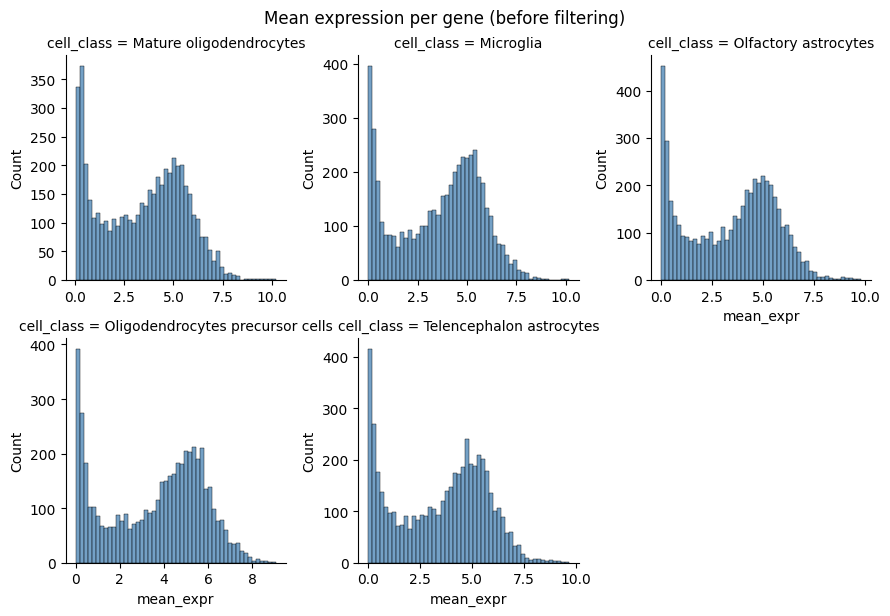

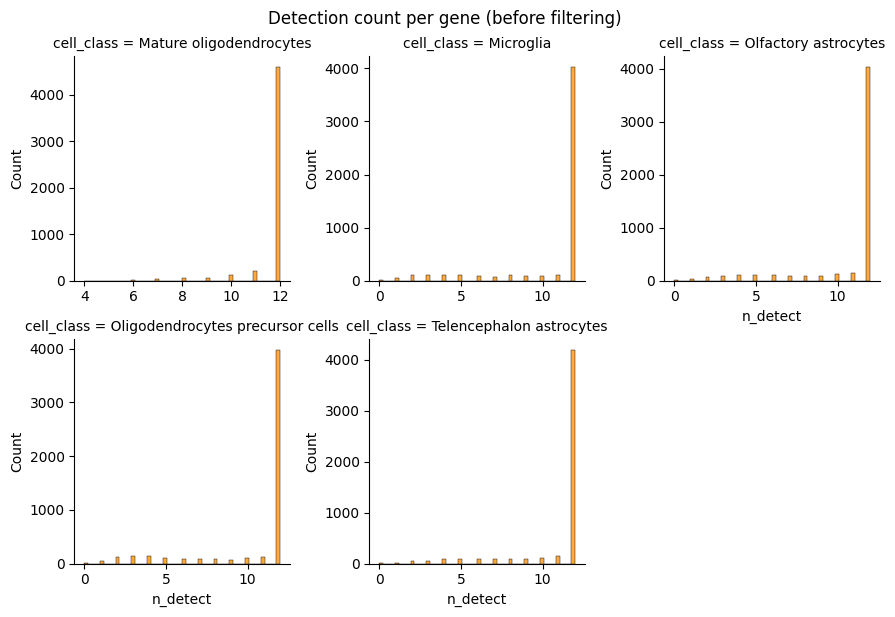

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# compute stats per gene and cell type
stats_all = (
    df_long
    .groupby(["cell_class", "gene"])
    .agg(
        mean_expr=("value", "mean"),
        n_detect=("value", lambda x: (x > 0).sum())
    )
    .reset_index()
)

# Plot distributions per cell type
g = sns.FacetGrid(stats_all, col="cell_class", col_wrap=3, sharex=False, sharey=False)
g.map(sns.histplot, "mean_expr", bins=50, color="steelblue")
g.fig.suptitle("Mean expression per gene (before filtering)", y=1.02)
plt.show()

g = sns.FacetGrid(stats_all, col="cell_class", col_wrap=3, sharex=False, sharey=False)
g.map(sns.histplot, "n_detect", bins=50, color="darkorange")
g.fig.suptitle("Detection count per gene (before filtering)", y=1.02)
plt.show()

In [7]:
# thresholds (edit to taste)
MIN_MEAN   = 3     # per (cell_type, gene) mean expression on log1p-CPM scale
MIN_DET    = 3       # gene must be detected (>0) in at least N samples within a cell type

def filter_low_genes(df_long, min_mean=MIN_MEAN, min_detect=MIN_DET):
    kept = []
    for ct, dfc in df_long.groupby("cell_class"):
        stats = (dfc
                 .groupby("gene")
                 .agg(mean_expr=("value","mean"),
                      n_detect=("value", lambda x: (x>0).sum()))
                 .reset_index())
        good = stats[(stats.mean_expr >= min_mean) & (stats.n_detect >= min_detect)].gene
        kept.append(dfc[dfc.gene.isin(good)])
    return pd.concat(kept, ignore_index=True)

df_filtered = filter_low_genes(df_long)
print("rows before:", len(df_long), "after:", len(df_filtered))

rows before: 306060 after: 186264


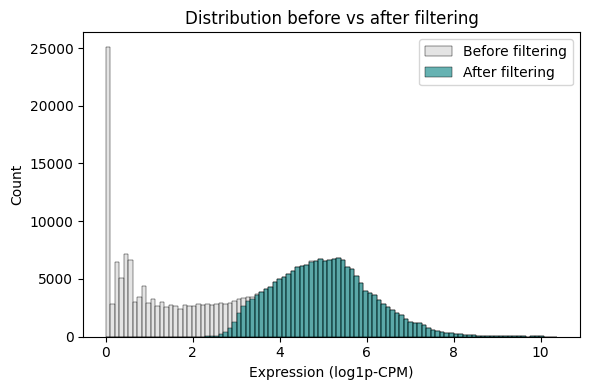

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compare all cell types pooled
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(df_long["value"], bins=100, label="Before filtering", color="lightgray", alpha=0.6)
sns.histplot(df_filtered["value"], bins=100, label="After filtering", color="teal", alpha=0.6)
plt.legend()
plt.xlabel("Expression (log1p-CPM)")
plt.title("Distribution before vs after filtering")
plt.tight_layout()
plt.show()

In [26]:
import pymc as pm
import arviz as az

def fit_gene_pymc_ac(df_gene, *, advi=False, draws=1000, tune=1000, chains=4,
                     target_accept=0.9, seed=42):
    """
    value ~ age + condition + age:condition + (1|sample)
    df_gene is one (cell_type, gene).
    """
    df = df_gene.copy()
    ages    = sorted(df["age"].astype(str).unique())
    conds   = sorted(df["condition"].astype(str).unique())
    samples = sorted(df["sample_id"].astype(str).unique())

    A = len(ages); C = len(conds); S = len(samples)

    age_idx    = df["age"].astype(str).apply(ages.index).to_numpy()
    cond_idx   = df["condition"].astype(str).apply(conds.index).to_numpy()
    sample_idx = df["sample_id"].astype(str).apply(samples.index).to_numpy()
    y          = df["value"].to_numpy()

    with pm.Model() as m:
        sigma         = pm.HalfNormal("sigma", 0.7)
        sigma_sample  = pm.HalfNormal("sigma_sample", 0.5)
        sample_offset = pm.Normal("sample_offset", 0.0, sigma_sample, shape=S)

        beta_age         = pm.Normal("beta_age", 0.0, 0.5, shape=A)
        beta_cond        = pm.Normal("beta_cond", 0.0, 0.5, shape=C)
        beta_interaction = pm.Normal("beta_interaction", 0.0, 0.5, shape=(A, C))

        mu = (
            beta_age[age_idx]
          + beta_cond[cond_idx]
          + beta_interaction[age_idx, cond_idx]
          + sample_offset[sample_idx]
        )

        pm.Normal("obs", mu, sigma, observed=y)

        if advi:
            approx = pm.fit(20_000, random_seed=seed, progressbar=False)
            idata  = approx.sample(draws)
        else:
            idata = pm.sample(draws=draws, tune=tune, chains=chains,
                              target_accept=target_accept, random_seed=seed,
                              return_inferencedata=True, progressbar=True)

    meta = {"ages": ages, "conds": conds}
    return idata, meta

def _summarize_1d(samples):
    q = np.quantile(samples, [0.025, 0.975])
    return float(samples.mean()), float(q[0]), float(q[1])

def summarize_effects_ac(idata, meta):
    """
    Report:
      - mtDSB_at_age  = (mtDSB - control) at each age
      - age_interaction(old-young) = difference of those contrasts between oldest and youngest age
    """
    ages  = meta["ages"]
    conds = [c.lower() for c in meta["conds"]]

    # indices for control & mtDSB
    i_ctrl = conds.index("control") if "control" in conds else 0
    i_mt   = conds.index("mtdsb")   if "mtdsb"   in conds else (1 if len(conds)>1 else 0)

    beta_cond = idata.posterior["beta_cond"].values.reshape(-1, len(conds))
    beta_int  = idata.posterior["beta_interaction"].values.reshape(-1, len(ages), len(conds))

    rows = []

    # mtDSB effect at each age
    for a, age in enumerate(ages):
        diff = (beta_cond[:, i_mt] - beta_cond[:, i_ctrl]) + (beta_int[:, a, i_mt] - beta_int[:, a, i_ctrl])
        mean, lo, hi = _summarize_1d(diff)
        rows.append({
            "effect": "mtDSB_at_age", "age": age,
            "mean": mean, "hdi_2.5%": lo, "hdi_97.5%": hi,
            "term": f"beta[{age}] (mtDSB effect @ age)"
        })

    # age interaction: oldest – youngest
    if len(ages) >= 2:
        a_lo, a_hi = 0, len(ages)-1
        d_hi = (beta_cond[:, i_mt] - beta_cond[:, i_ctrl]) + (beta_int[:, a_hi, i_mt] - beta_int[:, a_hi, i_ctrl])
        d_lo = (beta_cond[:, i_mt] - beta_cond[:, i_ctrl]) + (beta_int[:, a_lo, i_mt] - beta_int[:, a_lo, i_ctrl])
        ai  = d_hi - d_lo
        mean, lo, hi = _summarize_1d(ai)
        rows.append({
            "effect": "age_interaction", "age": f"{ages[a_hi]}–{ages[a_lo]}",
            "mean": mean, "hdi_2.5%": lo, "hdi_97.5%": hi,
            "term": f"age_interaction({ages[a_hi]} - {ages[a_lo]})"
        })
    return pd.DataFrame(rows)

In [27]:
def fit_many_genes_condition(df_long, genes, celltypes,
                             *, advi=False, draws=1000, tune=1000, chains=4,
                             target_accept=0.9, seed=42):
    rows = []
    for ct in celltypes:
        df_ct = df_long[df_long["cell_class"] == ct]
        for g in genes:
            sub = df_ct[df_ct["gene"] == g]
            if sub.empty:
                continue
            idata, meta = fit_gene_pymc_condition(
                sub, advi=advi, draws=draws, tune=tune,
                chains=chains, target_accept=target_accept, seed=seed
            )
            eff = summarize_condition_effect(idata, meta)
            eff.insert(0, "gene", g)
            eff.insert(0, "cell_class", ct)
            rows.append(eff)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

In [28]:
import pymc as pm
import numpy as np
import pandas as pd

def fit_gene_pymc_condition(df_gene,
                            advi=False,
                            draws=1000,
                            tune=1000,
                            chains=4,
                            target_accept=0.9,
                            seed=42):
    """
    Bayesian model for mtDSB vs control (condition only).
    """
    y = df_gene["value"].values
    cond = pd.Categorical(df_gene["condition"])
    cond_idx = cond.codes
    C = len(cond.categories)

    with pm.Model() as m:
        alpha = pm.Normal("alpha", 0, 1)
        sigma = pm.HalfNormal("sigma", 0.5)
        beta = pm.Normal("beta", 0, 1, shape=C)

        mu = alpha + beta[cond_idx]
        pm.Normal("obs", mu, sigma, observed=y)

        if advi:
            approx = pm.fit(20000, random_seed=seed)
            idata = approx.sample(draws)
        else:
            idata = pm.sample(
                draws=draws, tune=tune, chains=chains,
                target_accept=target_accept, random_seed=seed,
                return_inferencedata=True, progressbar=True
            )

    return idata, dict(categories=cond.categories.tolist())

In [29]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from tqdm import tqdm

def screen_condition_ols(df_long, cell_type, min_detect=3):
    """
    Fast per-gene OLS: value ~ condition, within one cell_type.
    Returns a DataFrame with effect size and p-value for condition[T.mtDSB].
    """
    sub = df_long[df_long["cell_class"] == cell_type]
    out = []
    for g, dfg in tqdm(sub.groupby("gene"), desc=f"Screening (OLS) in {cell_type}"):
        # minimal filtering to avoid degenerate fits
        if dfg["value"].gt(0).sum() < min_detect or dfg["condition"].nunique() < 2:
            continue
        try:
            m = smf.ols("value ~ C(condition)", data=dfg).fit()
            eff = m.params.get("C(condition)[T.mtDSB]", np.nan)
            p   = m.pvalues.get("C(condition)[T.mtDSB]", np.nan)
            out.append({"gene": g, "ols_effect": eff, "ols_p": p, "n": len(dfg)})
        except Exception:
            pass
    return pd.DataFrame(out).dropna()

In [30]:
from statsmodels.stats.multitest import multipletests

def make_shortlist(screen_df, top_k=300, by="abs_effect"):
    df = screen_df.copy()
    if "ols_p" in df.columns:
        df["ols_fdr"] = multipletests(df["ols_p"].values, method="fdr_bh")[1]
    if by == "abs_effect":
        df = df.reindex(df["ols_effect"].abs().sort_values(ascending=False).index)
    elif by == "fdr":
        df = df.sort_values("ols_fdr")
    return df.head(top_k)["gene"].tolist()

In [31]:
import pymc as pm
import arviz as az

def fit_gene_pymc_condition(df_gene,
                            advi=False,
                            draws=800, tune=800, chains=2, cores=2,
                            target_accept=0.9, seed=42):
    y = df_gene["value"].values
    cond = pd.Categorical(df_gene["condition"])
    cond_idx = cond.codes
    C = len(cond.categories)

    with pm.Model() as m:
        alpha = pm.Normal("alpha", 0, 1)
        sigma = pm.HalfNormal("sigma", 0.5)
        beta  = pm.Normal("beta", 0, 1, shape=C)   # condition main effects
        mu = alpha + beta[cond_idx]
        pm.Normal("obs", mu, sigma, observed=y)

        if advi:
            approx = pm.fit(20000, random_seed=seed, callbacks=[pm.callbacks.CheckParametersConvergence()])
            idata = approx.sample(draws, random_seed=seed)
        else:
            idata = pm.sample(draws=draws, tune=tune, chains=chains, cores=cores,
                              target_accept=target_accept, random_seed=seed,
                              return_inferencedata=True, progressbar=True)
    return idata, dict(categories=cond.categories.tolist())

def summarize_condition_effect(idata, meta):
    post = az.summary(idata, var_names=["beta"], hdi_prob=0.95).reset_index()
    post = post.rename(columns={"index": "param"})
    post["condition"] = meta["categories"]
    # Keep the mtDSB effect row only (if your categories are ['control','mtDSB'])
    return post

In [32]:
def fit_many_genes_condition(df_long, genes, celltypes,
                             *, advi=False, draws=800, tune=800, chains=2, cores=2,
                             target_accept=0.9, seed=42):
    rows = []
    for ct in celltypes:
        df_ct = df_long[df_long["cell_class"] == ct]
        for g in genes:
            sub = df_ct[df_ct["gene"] == g]
            if sub.empty or sub["condition"].nunique() < 2:
                continue
            idata, meta = fit_gene_pymc_condition(
                sub, advi=advi, draws=draws, tune=tune, chains=chains, cores=cores,
                target_accept=target_accept, seed=seed
            )
            eff = summarize_condition_effect(idata, meta)
            # keep only the mtDSB row if present
            eff = eff[eff["condition"].str.contains("mtDSB", case=False, na=False)]
            eff.insert(0, "gene", g)
            eff.insert(0, "cell_class", ct)
            rows.append(eff)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

In [33]:
# choose your cell type(s)
celltypes_of_interest = ["Mature oligodendrocytes"]

# --- fast screen ---
screen = screen_condition_ols(df_filtered, celltypes_of_interest[0])
shortlist = make_shortlist(screen, top_k=300, by="abs_effect")  # adjust K


Screening (OLS) in Mature oligodendrocytes: 100%|█| 2955/2955 [00:02<00:00, 1001


In [38]:
import pymc as pm
import arviz as az
import pandas as pd

def _ensure_condition_cats(series):
    if "control" in series.unique() and "mtDSB" in series.unique():
        return pd.Categorical(series, categories=["control","mtDSB"])
    return pd.Categorical(series)

def fit_gene_pymc_condition(
    df_gene,
    aggregate_by_sample=True,
    sample_col="sample",          # or "sample_id"
    advi=False,
    draws=800, tune=800, chains=2, cores=2,
    target_accept=0.9, seed=42,
    progressbar=False
):
    dg = df_gene.copy()

    # be forgiving about sample column name
    if aggregate_by_sample and sample_col not in dg.columns:
        if "sample_id" in dg.columns:
            sample_col = "sample_id"
        else:
            aggregate_by_sample = False  # no sample column → skip aggregation

    if aggregate_by_sample:
        dg = (dg.groupby([sample_col, "condition"], as_index=False)
                .agg(value=("value","mean")))

    cond = _ensure_condition_cats(dg["condition"])
    cond_idx = pd.Categorical(cond).codes
    C = len(pd.Categorical(cond).categories)
    y = dg["value"].values

    with pm.Model() as m:
        alpha = pm.Normal("alpha", 0, 1)
        sigma = pm.HalfNormal("sigma", 0.5)
        beta  = pm.Normal("beta", 0, 1, shape=C)   # condition main effects
        mu = alpha + beta[cond_idx]
        pm.Normal("obs", mu, sigma, observed=y)

        if advi:
            approx = pm.fit(
                20_000,
                random_seed=seed,
                callbacks=[pm.callbacks.CheckParametersConvergence()],
                progressbar=progressbar,   # OK here
            )
            idata = approx.sample(draws, random_seed=seed)  # ← NO progressbar kw here
        else:
            idata = pm.sample(
                draws=draws, tune=tune, chains=chains, cores=cores,
                target_accept=target_accept, random_seed=seed,
                return_inferencedata=True, progressbar=progressbar
            )

    return idata, {"categories": list(pd.Categorical(cond).categories)}

def summarize_condition_effect(idata, meta, hdi=0.95):
    s = az.summary(idata, var_names=["beta"], hdi_prob=hdi).reset_index().rename(columns={"index":"param"})
    s["condition"] = meta["categories"]
    if "mtDSB" in s["condition"].values:
        s = s[s["condition"] == "mtDSB"]
    return s

In [35]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

from joblib import Parallel, delayed
import pandas as pd
import numpy as np

def _fit_one_gene_cond(df_long, gene, cell_type, **kwargs):
    sub = df_long[(df_long["cell_class"]==cell_type) & (df_long["gene"]==gene)]
    if sub.empty or sub["condition"].nunique() < 2:
        return None
    # jitter seed so workers don’t reuse identical seeds
    kwargs = {**kwargs, "seed": (kwargs.get("seed", 42) + hash(gene) % 10_000)}
    idata, meta = fit_gene_pymc_condition(sub, **kwargs)
    eff = summarize_condition_effect(idata, meta)
    if eff.empty: 
        return None
    eff.insert(0, "gene", gene)
    eff.insert(0, "cell_class", cell_type)
    return eff

def fit_many_genes_condition_parallel(df_long, genes, celltypes, n_jobs=8, **kwargs):
    out = []
    for ct in celltypes:
        res = Parallel(n_jobs=n_jobs, backend="loky")(
            delayed(_fit_one_gene_cond)(
                df_long, g, ct,
                advi=True, draws=kwargs.get("draws",600), tune=0,
                chains=1, cores=1,                      # ADVI ignores cores
                target_accept=kwargs.get("target_accept",0.9),
                seed=kwargs.get("seed",42),
                aggregate_by_sample=kwargs.get("aggregate_by_sample",True)
            )
            for g in genes
        )
        ct_df = pd.concat([r for r in res if r is not None], ignore_index=True) if any(res) else pd.DataFrame()
        out.append(ct_df)
    return pd.concat([x for x in out if not x.empty], ignore_index=True) if out else pd.DataFrame()

In [36]:
df_filtered = df_filtered.rename(columns={"sample_id": "sample"})

In [39]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

from joblib import Parallel, delayed
import numpy as np

def _fit_one_gene_cond(df_long, gene, cell_type, **kwargs):
    sub = df_long[(df_long["cell_class"]==cell_type) & (df_long["gene"]==gene)]
    if sub.empty or sub["condition"].nunique() < 2:
        return None
    # jitter seed per gene so workers don’t collide
    kwargs = {**kwargs, "seed": (kwargs.get("seed", 42) + (hash(gene) % 10_000))}
    try:
        idata, meta = fit_gene_pymc_condition(sub, **kwargs)
        eff = summarize_condition_effect(idata, meta)
        if eff.empty:
            return None
        eff.insert(0, "gene", gene)
        eff.insert(0, "cell_class", cell_type)
        return eff
    except Exception as e:
        # optional: print(gene, "failed:", e)
        return None

def fit_many_genes_condition_parallel(df_long, genes, celltypes, n_jobs=8, **kwargs):
    out = []
    for ct in celltypes:
        res = Parallel(n_jobs=n_jobs, backend="loky")(
            delayed(_fit_one_gene_cond)(
                df_long, g, ct,
                advi=True,
                draws=kwargs.get("draws",600),
                tune=0, chains=1, cores=1,             # ADVI ignores cores
                target_accept=kwargs.get("target_accept",0.9),
                aggregate_by_sample=kwargs.get("aggregate_by_sample",True),
                sample_col=kwargs.get("sample_col","sample"),   # set to "sample_id" if needed
                progressbar=False
            )
            for g in genes
        )
        ct_df = [r for r in res if r is not None]
        if ct_df:
            out.append(pd.concat(ct_df, ignore_index=True))
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

In [40]:
# If your column is 'sample_id', either rename once:
# df_filtered = df_filtered.rename(columns={"sample_id": "sample"})

# …or pass sample_col="sample_id" below:
summary_fast = fit_many_genes_condition_parallel(
    df_filtered,
    genes=shortlist,
    celltypes=celltypes_of_interest,
    n_jobs=8,
    draws=600,
    target_accept=0.9,
    aggregate_by_sample=True,
    sample_col="sample_id"
)



Finished [100%]: Average Loss = 26.263
arviz - WARNING - Shape validation failed: input_shape: (1, 600), minimum_shape: (chains=2, draws=4)
Finished [100%]: Average Loss = 20.741
arviz - WARNING - Shape validation failed: input_shape: (1, 600), minimum_shape: (chains=2, draws=4)
Finished [100%]: Average Loss = 29.01
arviz - WARNING - Shape validation failed: input_shape: (1, 600), minimum_shape: (chains=2, draws=4)
Finished [100%]: Average Loss = 22.697
arviz - WARNING - Shape validation failed: input_shape: (1, 600), minimum_shape: (chains=2, draws=4)
Finished [100%]: Average Loss = 25.47
arviz - WARNING - Shape validation failed: input_shape: (1, 600), minimum_shape: (chains=2, draws=4)
Finished [100%]: Average Loss = 20.239
arviz - WARNING - Shape validation failed: input_shape: (1, 600), minimum_shape: (chains=2, draws=4)
Finished [100%]: Average Loss = 25.981
arviz - WARNING - Shape validation failed: input_shape: (1, 600), minimum_shape: (chains=2, draws=4)
Finished [100%]: Avera

In [86]:
# rank by |mean|
top_final = (summary_fast
             .sort_values("mean", key=lambda s: s.abs(), ascending=False)
             .groupby("cell_class").head(200)["gene"].unique().tolist())

In [87]:
len(top_final)

200

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_condition_effect_scatter(summary_df, cell_type, top_n=50, save=None):
    # filter one cell type
    d = summary_df[summary_df["cell_class"] == cell_type].copy()
    if d.empty:
        print(f"No data for {cell_type}")
        return

    # keep only mtDSB condition if others are present
    if "condition" in d.columns and d["condition"].nunique() > 1:
        d = d[d["condition"] == "mtDSB"]

    # rank by absolute mean effect
    d["abs_mean"] = d["mean"].abs()
    d = d.sort_values("abs_mean", ascending=False)

    plt.figure(figsize=(6, max(4, 0.25*len(d))))
    sns.scatterplot(data=d, x="mean", y="gene", s=40, color="C0", edgecolor="k", linewidth=0.3)
    # add HDI intervals as horizontal bars
    plt.hlines(y=d["gene"], xmin=d["hdi_2.5%"], xmax=d["hdi_97.5%"],
               color="gray", alpha=0.5, linewidth=2)

    plt.axvline(0, color="k", ls="--", lw=1)
    plt.title(f"{cell_type}\nPosterior mean ± 95% HDI (mtDSB vs control)")
    plt.xlabel("Posterior mean effect")
    plt.ylabel("")
    plt.tight_layout()

    if save:
        plt.savefig(save, dpi=200, bbox_inches="tight")
    plt.show()

/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_57175/3162996303.py:15: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  ax = sns.pointplot(
/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_57175/3162996303.py:15: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(


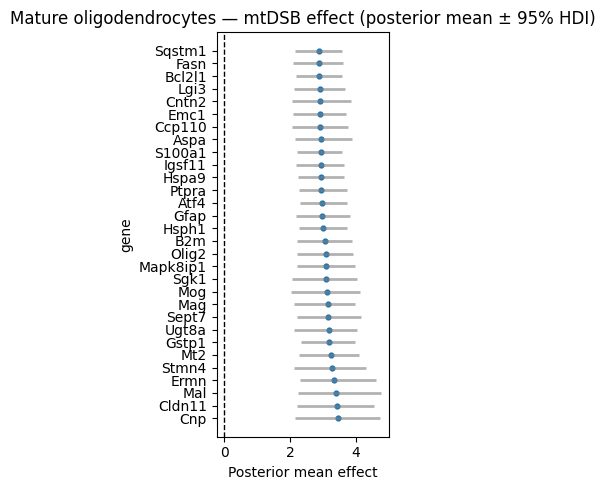

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_top_genes_caterpillar(summary_df, cell_class, genes, save=None):
    d = summary_df[(summary_df["cell_class"] == cell_class) & (summary_df["gene"].isin(genes))].copy()
    if d.empty:
        print(f"No data for {cell_class}")
        return
    
    # sort by mean effect
    d = d.sort_values("mean", ascending=True)
    d["gene"] = pd.Categorical(d["gene"], categories=d["gene"], ordered=True)
    
    plt.figure(figsize=(3, 0.1 * len(d) + 2))
    ax = sns.pointplot(
        data=d, y="gene", x="mean", join=False, color="C0",
        errorbar=None, scale=0.6
    )
    plt.hlines(y=d["gene"], xmin=d["hdi_2.5%"], xmax=d["hdi_97.5%"],
               color="gray", lw=2, alpha=0.6)
    plt.axvline(0, color="k", ls="--", lw=1)
    plt.title(f"{cell_class} — mtDSB effect (posterior mean ± 95% HDI)")
    plt.xlabel("Posterior mean effect")
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=200, bbox_inches="tight")
    plt.show()

# Example
plot_top_genes_caterpillar(summary_fast, "Mature oligodendrocytes", top_final[0:30])

In [91]:
df_sorted = (
    summary_fast.loc[summary_fast['gene'].isin(top_final)]
    .assign(order=lambda d: pd.Categorical(d['gene'], categories=top_final, ordered=True))
    .sort_values('order')
    .drop(columns='order')
)

In [92]:
df_sorted[df_sorted.gene == 'Serpina3n']

,cell_class,gene,param,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,condition
2,Mature oligodendrocytes,Serpina3n,beta[1],2.145,0.395,1.404,2.975,0.018,0.011,508.0,475.0,NaN,mtDSB


In [94]:
print(top_final) 

['Cnp', 'Cldn11', 'Mal', 'Ermn', 'Stmn4', 'Mt2', 'Gstp1', 'Ugt8a', 'Sept7', 'Mag', 'Mog', 'Sgk1', 'Mapk8ip1', 'Olig2', 'B2m', 'Hsph1', 'Gfap', 'Atf4', 'Ptpra', 'Hspa9', 'Igsf11', 'Aspa', 'S100a1', 'Ccp110', 'Cntn2', 'Emc1', 'Lgi3', 'Bcl2l1', 'Fasn', 'Sqstm1', 'Tppp', 'Nfe2l1', 'Nkx6-2', 'Cpox', 'H2-D1', 'Zbtb16', 'Gng11', 'Mpzl1', 'Plin4', 'Coro1c', 'Prr5l', 'P4hb', 'Rap1a', 'Gars', 'Rnf144a', 'Slc6a8', 'Myo1d', 'Ero1l', 'Adgrg1', 'Tnpo1', 'Dync1li1', 'H2-K1', 'Cab39l', 'Adamts1', 'Yars', 'Atf5', 'Etv5', 'Nr1d1', 'Mpp2', 'Sox8', 'Mast2', 'Kcnip3', 'Ptch1', 'Rnaset2a', 'Arid5b', 'Gfra1', 'Zfp281', 'Anln', 'Jade2', 'Shtn1', 'Peg10', 'Vegfa', 'Sez6l2', 'S1pr5', 'Sema6d', 'Grm3', 'Ece1', 'Syt4', 'Bcl6', 'Grn', 'Calu', 'Myh9', 'Sox2', 'Fkbp5', 'Rapgef3', 'Traf6', 'Mdm2', 'Opalin', 'Chka', 'Ddit3', 'Bax', 'Arhgef28', 'Abca1', 'Egr1', 'Cebpg', 'Gaa', 'Dixdc1', 'Ddx21', 'Gpd1', 'Vat1', 'Ptbp1', 'Enpp6', 'Lpin1', 'Nmu', 'Ssrp1', 'Flna', 'Per1', 'Hexa', 'Dock5', 'Cyb5r3', 'Dusp6', 'Mybbp1a', 'Tf

In [95]:
gene_modules_mtDSB_OL = {
    # --- 1. Core myelin and OL identity ---
    "myelin_identity": {
        "genes": [
            "Cnp", "Mog", "Mag", "Mbp", "Plp1", "Mal", "Ermn", "Ugt8a", 
            "Cldn11", "Stmn4", "Opalin", "Tppp", "Olig2", "Nkx6-2", "Sox8", "Sox21", "Pou3f1"
        ],
        "desc": "Canonical oligodendrocyte and myelin structure genes; reduced under mtDSB stress, suggesting impaired myelin maintenance or dedifferentiation."
    },

    # --- 2. Mitochondrial stress and ISR ---
    "mitochondrial_ISR": {
        "genes": [
            "Atf4", "Atf5", "Ddit3", "Hspa9", "Hspa1a", "Hsph1", "Tfeb",
            "Mt2", "Gstp1", "Hsf1", "Tiparp", "Txnip", "Sesn2", "Rcan1", 
            "Nfe2l1", "Bach2", "Acsl1"
        ],
        "desc": "Integrated stress response and mitochondrial unfolded protein response (UPRmt); driven by ATF4/CHOP and heat shock pathways, with antioxidant and proteostasis activation."
    },

    # --- 3. Oxidative stress and detoxification ---
    "oxidative_stress": {
        "genes": ["Mt2", "Gstp1", "Hspa9", "Hsph1", "Ero1l", "Hspa1a", "Tiparp", "Sesn2", "Txnip"],
        "desc": "Antioxidant and ROS detoxification; redox balancing via metallothionein, glutathione transferases, and stress chaperones."
    },

    # --- 4. Apoptosis and survival signaling ---
    "apoptosis_survival": {
        "genes": ["Bcl2l1", "Bax", "Ddit3", "Atf4", "Traf6", "Fkbp5", "Sgk1", "Mapk8ip1", "Gars", "Rap1a", "Rapgef3"],
        "desc": "Co-activation of pro- and anti-apoptotic programs; adaptation to maintain survival under mitochondrial stress."
    },

    # --- 5. Lipid metabolism and myelin biogenesis ---
    "lipid_metabolism": {
        "genes": ["Fasn", "Lpin1", "Abca1", "Pla2g4a", "Acsl1", "Cyp27a1", "P4hb", "Ugt8a", "Mal", "Cldn11"],
        "desc": "Myelin lipid synthesis and remodeling; indicates metabolic rewiring of membrane production under stress."
    },

    # --- 6. Mitochondrial and metabolic regulation ---
    "metabolic_regulation": {
        "genes": ["Cpox", "Gars", "Yars", "Ero1l", "Cab39l", "Slc6a8", "Sgpl1", "Idi1", "Acsl1", "Nfe2l1", "Tfeb", "Atad3a"],
        "desc": "Mitochondrial translation, redox balance, creatine metabolism, and heme synthesis; broad mitochondrial adaptation."
    },

    # --- 7. Cytoskeletal and morphological remodeling ---
    "cytoskeleton": {
        "genes": ["Sept7", "Coro1c", "Myh9", "Dync1li1", "Anln", "Arhgef28", "Msn", "Flna"],
        "desc": "Cytoskeletal and process retraction genes; indicates morphological changes in stressed oligodendrocytes."
    },

    # --- 8. Transcriptional and nuclear regulators ---
    "transcriptional_regulators": {
        "genes": ["Zbtb16", "Cebpg", "Etv5", "Egr1", "Bcl6", "Arid5b", "Nr1d1", "Klf15", "Bach2", "Nkx6-2", "Sox8", "Sox21", "Pou3f1"],
        "desc": "Transcription factors mediating reprogramming, dedifferentiation, and metabolic stress response."
    },

    # --- 9. ER–Golgi and protein processing ---
    "ER_stress": {
        "genes": ["P4hb", "Calu", "Rcc2", "Wdr5", "Epb41l3", "Lmna", "Cemip2", "Tiparp"],
        "desc": "ER–Golgi stress response and protein processing; overlap with UPR and chromatin remodeling."
    },

    # --- 10. Immune and inflammatory signaling ---
    "immune_signaling": {
        "genes": ["B2m", "H2-D1", "H2-K1", "C4b", "Csf1", "Cd151", "Traf6", "Grn", "Rcan1"],
        "desc": "MHC-I induction and complement signaling; characteristic of immune-reactive oligodendrocytes in inflammatory or degenerative contexts."
    },

    # --- 11. Circadian and metabolic coupling ---
    "circadian_metabolic": {
        "genes": ["Per1", "Per2", "Nr1d1"],
        "desc": "Circadian rhythm and metabolic coupling; disrupted by mitochondrial stress."
    },

    # --- 12. Miscellaneous / emerging candidates ---
    "other_stress_remodeling": {
        "genes": [
            "Vegfa", "Ece1", "Sema6d", "Gfra1", "Serpina3n", "Dll1", "Mdm2", 
            "Epb41l3", "Fgfr1", "Ephb2", "Vcl", "Lgals1", "Pmp22"
        ],
        "desc": "Tissue remodeling, angiogenic, and signaling molecules induced under chronic mitochondrial stress."
    }
}

In [97]:
all_genes_mtDSB = sorted({g for v in gene_modules_mtDSB_OL.values() for g in v["genes"]})

In [98]:
for module, meta in gene_modules_mtDSB_OL.items():
    subset = summary_fast[summary_fast["gene"].isin(meta["genes"])]
    print(module, subset["mean"].mean())

myelin_identity 2.9146
mitochondrial_ISR 2.474176470588235
oxidative_stress 2.562666666666667
apoptosis_survival 2.6682727272727274
lipid_metabolism 2.6438
metabolic_regulation 2.4142500000000005
cytoskeleton 2.51
transcriptional_regulators 2.387846153846154
ER_stress 2.209625
immune_signaling 2.4045555555555556
circadian_metabolic 2.1999999999999997
other_stress_remodeling 2.222923076923077


In [100]:
import pandas as pd

# create gene-to-module lookup
gene_to_module = {}
for module, meta in gene_modules_mtDSB_OL.items():
    for g in meta["genes"]:
        gene_to_module[g] = module

In [101]:
summary_fast["module"] = summary_fast["gene"].map(gene_to_module)

In [102]:
summary_mod = summary_fast.dropna(subset=["module"]).copy()

In [105]:
summary_mod

,cell_class,gene,param,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,condition,module
2,Mature oligodendrocytes,Serpina3n,beta[1],2.145,0.395,1.404,2.975,0.018,0.011,508.0,475.0,NaN,mtDSB,other_stress_remodeling
6,Mature oligodendrocytes,Atf5,beta[1],2.573,0.355,1.889,3.294,0.015,0.009,551.0,413.0,NaN,mtDSB,mitochondrial_ISR
7,Mature oligodendrocytes,Sesn2,beta[1],2.073,0.293,1.511,2.594,0.012,0.008,549.0,506.0,NaN,mtDSB,oxidative_stress
8,Mature oligodendrocytes,Fkbp5,beta[1],2.382,0.280,1.862,2.954,0.013,0.009,503.0,543.0,NaN,mtDSB,apoptosis_survival
16,Mature oligodendrocytes,H2-D1,beta[1],2.794,0.356,2.098,3.518,0.017,0.011,436.0,456.0,NaN,mtDSB,immune_signaling
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,Mature oligodendrocytes,Bach2,beta[1],2.193,0.280,1.646,2.704,0.012,0.008,585.0,485.0,NaN,mtDSB,transcriptional_regulators
291,Mature oligodendrocytes,Sept7,beta[1],3.154,0.497,2.193,4.138,0.022,0.016,518.0,336.0,NaN,mtDSB,cytoskeleton
292,Mature oligodendrocytes,Grn,beta[1],2.403,0.290,1.844,2.947,0.013,0.008,494.0,622.0,NaN,mtDSB,immune_signaling
294,Mature oligodendrocytes,Lmna,beta[1],2.185,0.274,1.633,2.694,0.011,0.008,598.0,611.0,NaN,mtDSB,ER_stress


In [106]:
module_summary = (
    summary_mod.groupby(["cell_class", "module"])
    .agg(mean_effect=("mean", "mean"),
         mean_hdi_low=("hdi_2.5%", "mean"),
         mean_hdi_high=("hdi_97.5%", "mean"),
         n_genes=("gene", "count"))
    .reset_index()
)

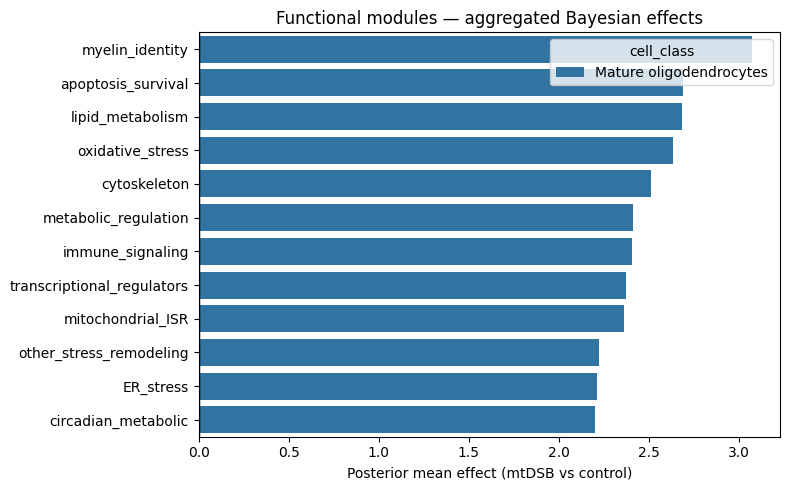

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.barplot(
    data=module_summary.sort_values("mean_effect", ascending=False),
    y="module", x="mean_effect", hue="cell_class", dodge=True
)
plt.axvline(0, color="k", lw=1)
plt.xlabel("Posterior mean effect (mtDSB vs control)")
plt.ylabel("")
plt.title("Functional modules — aggregated Bayesian effects")
plt.tight_layout()
plt.show()

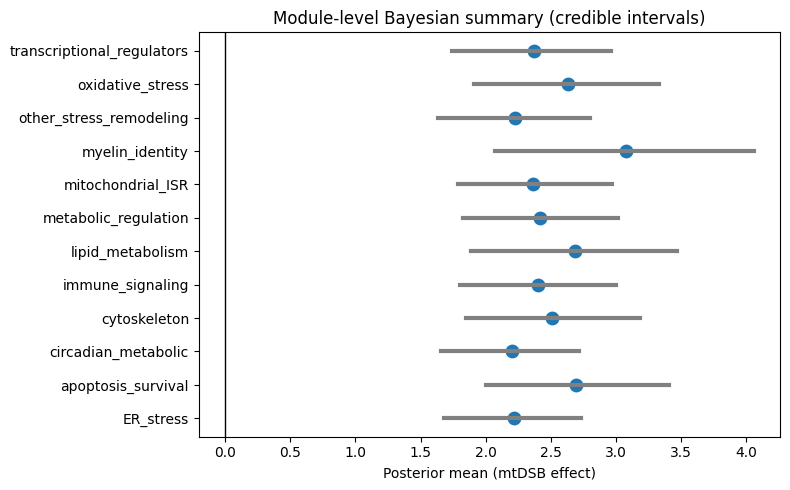

In [108]:
plt.figure(figsize=(8, 5))
for i, row in module_summary.iterrows():
    plt.plot([row["mean_hdi_low"], row["mean_hdi_high"]], [i, i], color="grey", lw=3)
    plt.scatter(row["mean_effect"], i, s=80, color="C0")
plt.yticks(range(len(module_summary)), module_summary["module"])
plt.axvline(0, color="k", lw=1)
plt.xlabel("Posterior mean (mtDSB effect)")
plt.title("Module-level Bayesian summary (credible intervals)")
plt.tight_layout()
plt.show()

In [114]:
module_summary["prob_positive"] = (
    summary_mod.groupby("module")["mean"]
    .apply(lambda x: (x > 0).mean())
)

In [115]:
module_summary

,cell_class,module,mean_effect,mean_hdi_low,mean_hdi_high,n_genes,prob_positive
0,Mature oligodendrocytes,ER_stress,2.214286,1.682571,2.732143,7,NaN
1,Mature oligodendrocytes,apoptosis_survival,2.690556,2.004111,3.410222,9,NaN
2,Mature oligodendrocytes,circadian_metabolic,2.200000,1.659000,2.717667,3,NaN
3,Mature oligodendrocytes,cytoskeleton,2.510000,1.846125,3.183750,8,NaN
4,Mature oligodendrocytes,immune_signaling,2.404556,1.801222,3.000778,9,NaN
5,Mature oligodendrocytes,lipid_metabolism,2.683625,1.887000,3.465125,8,NaN
6,Mature oligodendrocytes,metabolic_regulation,2.414250,1.828667,3.017833,12,NaN
7,Mature oligodendrocytes,mitochondrial_ISR,2.363500,1.790000,2.973000,2,NaN
8,Mature oligodendrocytes,myelin_identity,3.075125,2.074375,4.056250,8,NaN
9,Mature oligodendrocytes,other_stress_remodeling,2.222923,1.631385,2.803923,13,NaN
